In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Methodology and Model Selection

- Random Forest is selected because it captures nonlinear relationships and feature interactions that linear models (e.g. Lasso) miss.
- Date is engineered into numeric calendar features (Year and Month) so the model can learn seasonal and trend effects.
- The model is tuned with time-series cross-validation to prevent temporal leakage and improve generalization.

In [26]:
df = pd.read_csv('../data/combined_monthly.csv')
y = df['SP500']
X = df.drop(columns=['SP500'])

X['Date'] = pd.to_datetime(X['Date'])
X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month
X = X.drop(columns=['Date'])

feature_names = X.columns.tolist()

# Print out X and Y
X.head()
y

0      1286.119995
1      1327.219971
2      1325.829956
3      1363.609985
4      1320.640015
          ...     
133    4845.649902
134    5096.270020
135    5254.350098
136    5035.689941
137    5277.509766
Name: SP500, Length: 138, dtype: float64

In [27]:
# Time-aware split: earlier months for training, later months for testing
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [28]:
# Tune Random Forest with time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}
rf_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

rf = rf_search.best_estimator_
print(f"Best params: {rf_search.best_params_}")
print(f"Best CV RMSE: {np.sqrt(-rf_search.best_score_):.4f}")

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV RMSE: 648.9769


In [29]:
# Random Forest predictions and evaluation metrics
y_pred_rf = rf.predict(X_test)

rf_metrics = {
    'MSE': mean_squared_error(y_test, y_pred_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf),
}

print(pd.Series(rf_metrics).round(4))

MSE     203516.7162
RMSE       451.1283
MAE        348.6128
R2          -0.0442
dtype: float64


Feature importances:
CPI                  0.783066
Year                 0.086793
Copper               0.060201
Unemployment_Rate    0.040938
Steel_PPI            0.015243
US_10Y_Yield         0.007608
Crude_Oil            0.004336
Month                0.001816
dtype: float64


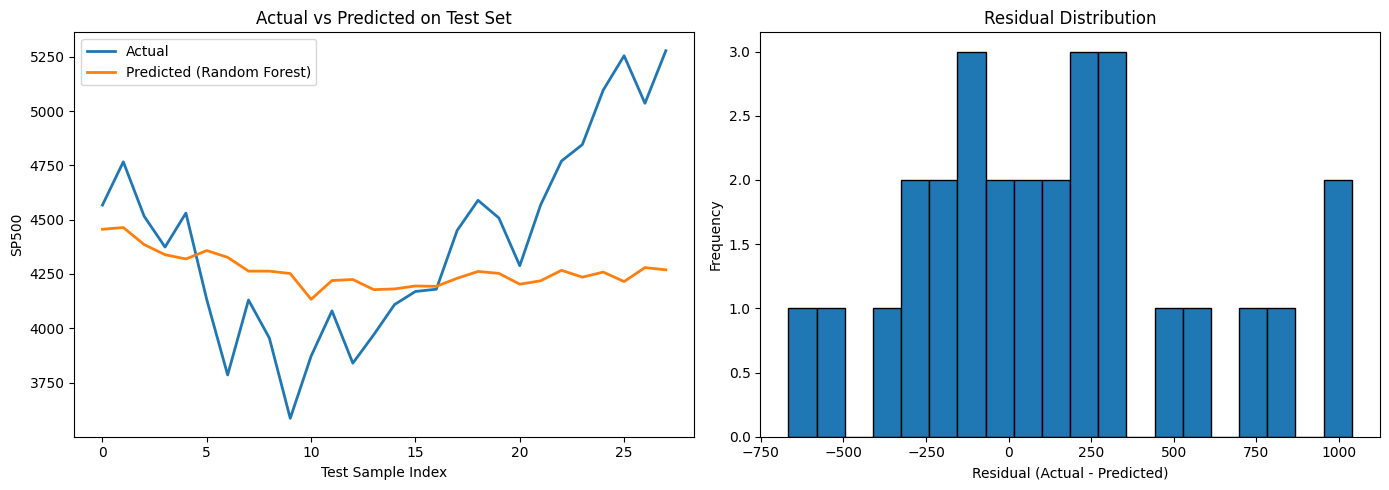

In [30]:
# Feature importance from the Random Forest (built-in, based on impurity reduction)
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Feature importances:")
print(importances)

residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(y_test.values, label='Actual', linewidth=2)
axes[0].plot(y_pred_rf, label='Predicted (Random Forest)', linewidth=2)
axes[0].set_title('Actual vs Predicted on Test Set')
axes[0].set_xlabel('Test Sample Index')
axes[0].set_ylabel('SP500')
axes[0].legend()

axes[1].hist(residuals, bins=20, edgecolor='black')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Experimental Design, Results, and Limitations

- Data split is time-aware (first 80% train, last 20% test) to reduce temporal leakage.
- Hyperparameter tuning uses TimeSeriesSplit cross-validation over `n_estimators`, `max_depth`, and `min_samples_split`.
- No feature scaling is applied (tree models do not require scaling), which avoids leakage from fitting a scaler before CV.
- Results are reported with MSE, RMSE, MAE, and R², then diagnosed with prediction and residual plots.
- Feature importance is derived from the Random Forest's built-in impurity-based metric, which ranks features by predictive contribution.
- Limitations: Random Forests can overfit on small datasets and may extrapolate poorly to market regimes not seen during training.